# Treinamento e Avaliação da Rede Neural Convolucional (BearingCNN)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT gerados a partir do dataset CWRU (4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Executar o treinamento da arquitetura `BearingCNN` através do módulo `src.cnn_processor`, restaurando automaticamente os pesos da época ótima (menor `val_loss`) para a avaliação no conjunto de teste.

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [11]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Importar módulos centralizados de src/
from src.config import NUM_EPOCHS, LEARNING_RATE
from src.cnn_processor import train_and_evaluate_bearing_cnn
from src.visualization import plot_training_curves, plot_confusion_matrix


## 2. Execução do Treinamento com Checkpointing Automático

A função `train_and_evaluate_bearing_cnn` gerencia a fase de treino e validação, salva o checkpoint do menor `val_loss` e avalia o modelo no conjunto de teste inédito.

In [12]:
# Executar o pipeline de treinamento da BearingCNN em 1 linha
res = train_and_evaluate_bearing_cnn(num_epochs=NUM_EPOCHS, lr=LEARNING_RATE)


[INFO] EXPERIMENTO BEARING CNN (PRÓPRIA) | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.1151 - Acc: 96.28% | Val Loss: 0.0018 - Acc: 99.96% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0048 - Acc: 99.89% | Val Loss: 0.0072 - Acc: 99.83% 
Época [03/10] | Treino Loss: 0.0024 - Acc: 99.94% | Val Loss: 0.0005 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0126 - Acc: 99.63% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0006 - Acc: 100.00% | Val Loss: 0.0014 - Acc: 99.96% 
Época [06/10] | Treino Loss: 0.0065 - Acc: 99.76% | Val Loss: 0.0002 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 06/10.
Época [07/10] | Treino Loss: 0.0005 - Acc: 99.99% | Val Loss: 0.0000 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/10] | Treino Loss: 0.0021 - Acc: 99.96% | Val Loss: 0.0001 - Acc: 100.00% 
Época [09/10] | Treino

## 3. Curvas de Aprendizado (Perda e Acurácia)

[INFO] Figura salva em: ../docs/images/training_curves_bearing_cnn.png


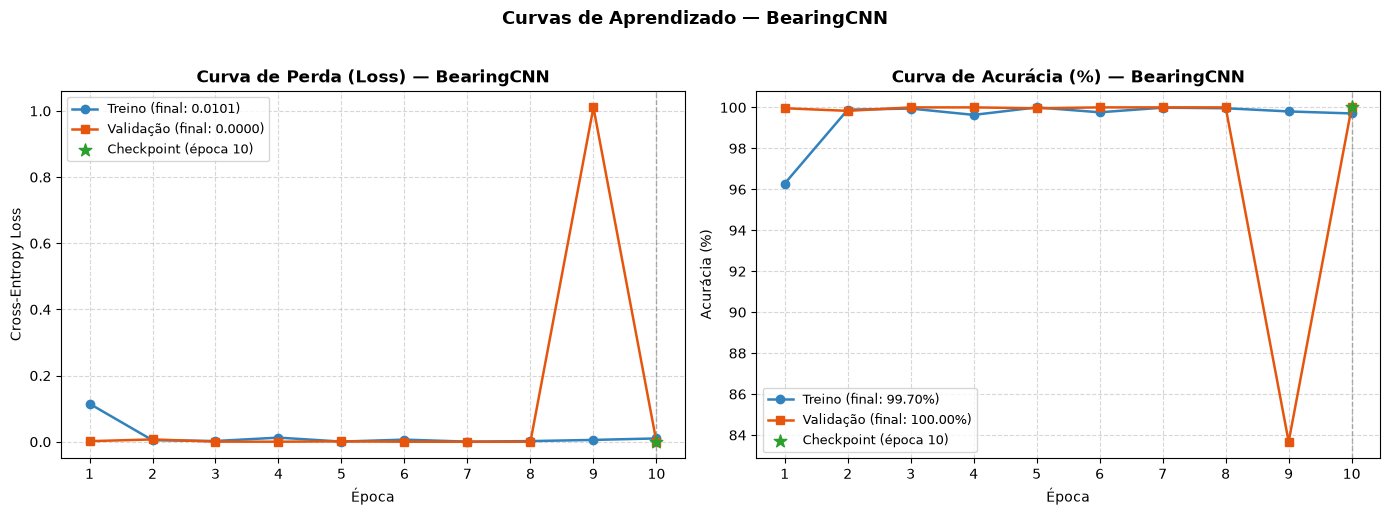

In [13]:
plot_training_curves(res['history'], 'BearingCNN', save_path='../docs/images/training_curves_bearing_cnn.png')


## 4. Relatório de Classificação Detalhado

In [14]:
print('================================================================================')
print(' RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (BEARING CNN) ')
print('================================================================================')
print(classification_report(res['test_labels'], res['test_preds'], target_names=res['classes'], digits=4))

 RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (BEARING CNN) 
              precision    recall  f1-score   support

        ball     0.9541    0.9239    0.9388       473
  inner_race     0.9762    0.9556    0.9658       473
      normal     1.0000    1.0000    1.0000       947
  outer_race     0.9500    1.0000    0.9744       475

    accuracy                         0.9759      2368
   macro avg     0.9701    0.9699    0.9697      2368
weighted avg     0.9761    0.9759    0.9758      2368



## 5. Matriz de Confusão

[INFO] Figura salva em: ../docs/images/confusion_matrix_bearing_cnn.png


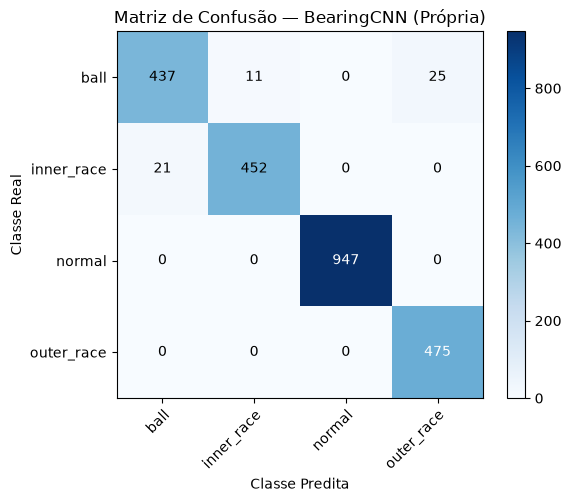

In [15]:
# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res, 'BearingCNN (Própria)', save_path='../docs/images/confusion_matrix_bearing_cnn.png')
